# DDRM — Diffusion Restoration for Beam-Erased Kinematics

Trains an **unconditional** diffusion prior over clean disk channel maps, then restores the
self-gravitating dirty cube with DDRM using the measured beam operator.

**Why:** the beam alone erases the GI wiggle (residual RMS 1.394 → 0.174, r=0.116 vs truth).
A denoiser cannot undo that. DDRM can, in principle, because it reconstructs what the
instrument could not measure.

**Target to beat:** wiggle residual correlation 0.116 (beam-only floor). Above that is real
recovery; at that level the prior is hallucinating.

## 0. Bootstrap

In [1]:
import os, sys, subprocess, glob

ON_KAGGLE = os.path.exists('/kaggle')
BRANCH = 'midterm-prep'
if ON_KAGGLE:
    REPO = '/kaggle/working/EXXA'; PKG = os.path.join(REPO, 'DENOISING_DIFFUSION')
    if not os.path.exists(REPO):
        subprocess.run(['git','clone','--branch',BRANCH,'--depth','1',
                        'https://github.com/KrishanYadav333/EXXA.git',REPO], check=True)
    else:
        subprocess.run(['git','-C',REPO,'fetch','origin',BRANCH], check=True)
        subprocess.run(['git','-C',REPO,'reset','--hard','origin/'+BRANCH], check=True)
    subprocess.run([sys.executable,'-m','pip','install','-q','--no-deps',
                    'pytorch-msssim','bettermoments'], check=True)
    os.chdir(os.path.join(PKG,'notebooks')); sys.path.insert(0, PKG)

    # Locate by the run_<id>_<step>_rt_<pp> folder structure split_cubes requires. A loose
    # '*dirty*.fits' glob matches dirty_sg.fits from the self-gravitating Dataset and points
    # DATA_DIR at the wrong dataset entirely.
    import re
    run_re = re.compile(r'run_\d+_\d+_rt_\d+', re.I)
    roots = {}
    for p in glob.glob('/kaggle/input/**/run_*', recursive=True):
        if os.path.isdir(p) and run_re.search(os.path.basename(p)):
            roots.setdefault(os.path.dirname(p), 0)
            roots[os.path.dirname(p)] += 1
    if not roots:
        raise FileNotFoundError(
            'No run_<id>_<step>_rt_<pp> folders under /kaggle/input. '
            'Attach the line-emission Dataset.\n'
            f'Attached: {sorted(glob.glob("/kaggle/input/*")) or "(nothing)"}')
    DATA_DIR = max(roots, key=roots.get)
    print(f'found {roots[DATA_DIR]} run folders')

    sg = glob.glob('/kaggle/input/**/clean_sg.fits', recursive=True)
    SG_DIR = os.path.dirname(sg[0]) if sg else None
else:
    if os.path.basename(os.getcwd()) != 'notebooks' and os.path.isdir('notebooks'):
        os.chdir('notebooks')
    sys.path.insert(0, os.path.abspath('..'))
    DATA_DIR = '../Line Emission Data'
    SG_DIR = '../self-gravitating cube and dirty cube/kinematic_data_v2'

print('cwd:', os.getcwd())
print('DATA_DIR:', DATA_DIR)
print('SG_DIR  :', SG_DIR or 'NOT FOUND — section 5 will be skipped')

Cloning into '/kaggle/working/EXXA'...
Updating files: 100% (5412/5412), done.


found 14 run folders
cwd: /kaggle/working/EXXA/DENOISING_DIFFUSION/notebooks
DATA_DIR: /kaggle/input/datasets/krishanyadav333/line-emission-data/Line Emission Data
SG_DIR  : /kaggle/input/datasets/krishanyadav333/self-gravitating-v2/kinematic_data_v2


## 0b. Pull latest `src/` (no kernel restart)

In [2]:
import importlib, subprocess, sys
if ON_KAGGLE:
    subprocess.run(['git','-C','/kaggle/working/EXXA','fetch','origin',BRANCH], check=True)
    subprocess.run(['git','-C','/kaggle/working/EXXA','reset','--hard','origin/'+BRANCH], check=True)
    print(subprocess.run(['git','-C','/kaggle/working/EXXA','log','-1','--oneline'],
                         capture_output=True, text=True).stdout.strip())

for m in [m for m in list(sys.modules) if m.startswith('src.')]:
    importlib.reload(sys.modules[m])
print('src/ reloaded')

HEAD is now at 66c54a3 fix(nb07): scoring reported a degenerate Keplerian fit as "RECOVERY"
66c54a3 fix(nb07): scoring reported a degenerate Keplerian fit as "RECOVERY"
src/ reloaded


From https://github.com/KrishanYadav333/EXXA
 * branch            midterm-prep -> FETCH_HEAD


## 1. Config

In [3]:
import time
import numpy as np
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

from src.data.cube_split import split_cubes
from src.data.fits_cube_dataset import FITSChannelDataset

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
N_GPU = torch.cuda.device_count()
SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

TARGET_SIZE = 256
N_SAMPLES   = 150      # channels per cube
BATCH_SIZE  = 8
EPOCHS      = 60
LR          = 2e-5
PREDICTION  = 'v'      # v + min_snr_gamma=5 converged best in notebook 06
MIN_SNR     = 5.0

CKPT = '../results/checkpoints/ddrm_prior.pth'
os.makedirs(os.path.dirname(CKPT), exist_ok=True)

print(f'device: {device} | GPUs: {N_GPU}')
print(f'{TARGET_SIZE}px | batch {BATCH_SIZE} | {EPOCHS} epochs | {PREDICTION}-prediction')

device: cuda | GPUs: 2
256px | batch 8 | 60 epochs | v-prediction


## 2. Data — clean channel maps only

The prior is over clean images. `FITSChannelDataset` returns `(dirty, clean)`; we keep the
clean half. Same Jy/beam domain as `clean_sg.fits`.

In [4]:
train_cubes, val_cubes, holdout_cubes = split_cubes(
    data_dir=DATA_DIR, n_holdout=3, val_fraction=0.2, seed=SEED)

_ds_kw = dict(n_samples=N_SAMPLES, target_size=TARGET_SIZE, seed=SEED,
              subtract_continuum=True, continuum_n=5, verbose=False)
train_pairs = FITSChannelDataset(train_cubes, **_ds_kw)
val_pairs   = FITSChannelDataset(val_cubes, **_ds_kw)


class CleanOnly(torch.utils.data.Dataset):
    """(dirty, clean) -> clean. The prior never sees a dirty image."""
    def __init__(self, pairs): self.pairs = pairs
    def __len__(self): return len(self.pairs)
    def __getitem__(self, i): return self.pairs[i][1]


train_ds, val_ds = CleanOnly(train_pairs), CleanOnly(val_pairs)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=(N_GPU > 0), drop_last=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f'train {len(train_ds)} | val {len(val_ds)} images')
_x = train_ds[0]
print(f'sample: {tuple(_x.shape)}  range [{_x.min():.3f}, {_x.max():.3f}]')
assert _x.shape[0] == 1, 'prior expects single-channel clean images'

CUBE-LEVEL SPLIT (grouped by RunID — no channel-level leakage)
  data_dir          : /kaggle/input/datasets/krishanyadav333/line-emission-data/Line Emission Data
  total cubes       : 14  across 11 distinct RunIDs
  seed=42  n_holdout=3  val_fraction=0.2
----------------------------------------------------------------------
  TRAIN   :  7 cubes | RunIDs ['0006', '0010', '0020', '0022', '0030', '0035']
  VAL     :  2 cubes | RunIDs ['0016', '0036']
  HOLDOUT :  5 cubes | RunIDs ['0002', '0025', '0026']  <-- inference only, NEVER trained/validated
----------------------------------------------------------------------
  HOLDOUT cube folders (reserved for moment-map evaluation):
    - run_0002_00560_rt_00
    - run_0002_00560_rt_01
    - run_0002_00560_rt_04
    - run_0025_01000_rt_04
    - run_0026_00005_rt_04
train 1050 | val 300 images
sample: (1, 256, 256)  range [0.447, 0.485]


## 3. Train the unconditional prior

In [5]:
from src.models.diffusion_unet import default_diffusion_config
from src.training.diffusion import DenoisingDiffusion

cfg = default_diffusion_config(image_size=TARGET_SIZE)
cfg.data.conditional = False           # p(clean), not p(clean|dirty)
cfg.diffusion.prediction_type = PREDICTION
cfg.diffusion.min_snr_gamma = MIN_SNR
cfg.diffusion.beta_schedule = 'cosine'

runner = DenoisingDiffusion(config=cfg, device=str(device), lr=LR, checkpoint_path=CKPT)
print(f'params: {sum(p.numel() for p in runner._core.parameters())/1e6:.1f}M')

t0 = time.time()
history = runner.train(train_loader, val_loader, n_epochs=EPOCHS, verbose=True)
print(f'\ntrained in {(time.time()-t0)/60:.1f} min -> {CKPT}')

params: 16.9M
Unconditional DDPM training
  params : 16,884,097
  device : cuda (DataParallel x2), timesteps: 1000
[epoch   1/60] train 8106.6877 | val 1115.1856  *best  (110.0s)
[epoch   2/60] train 645.3284 | val 482.9634  *best  (112.3s)
[epoch   3/60] train 319.2184 | val 291.2276  *best  (112.9s)
[epoch   4/60] train 214.7990 | val 202.0788  *best  (114.3s)
[epoch   5/60] train 155.1444 | val 146.7737  *best  (116.2s)
[epoch   6/60] train 115.7001 | val 140.1484  *best  (115.6s)
[epoch   7/60] train 91.3840 | val 97.9849  *best  (116.8s)
[epoch   8/60] train 77.1598 | val 87.0114  *best  (115.9s)
[epoch   9/60] train 66.7271 | val 68.1069  *best  (115.5s)
[epoch  10/60] train 56.2833 | val 62.5869  *best  (116.2s)
[epoch  11/60] train 49.8998 | val 59.4418  *best  (116.2s)
[epoch  12/60] train 48.4924 | val 58.6231  *best  (115.9s)
[epoch  13/60] train 46.2476 | val 50.7691  *best  (115.7s)
[epoch  14/60] train 44.5778 | val 53.4615  (115.8s)
[epoch  15/60] train 42.4616 | val 54.

In [6]:
# Persist immediately (RULES.md #1) — CKPT_DIR is inside the git clone the bootstrap wipes.
import shutil
if ON_KAGGLE:
    out = '/kaggle/working/ddrm_prior.pth'
    shutil.copy2(CKPT, out)
    print('persisted ->', out, f'({os.path.getsize(out)/1e6:.0f} MB)')

persisted -> /kaggle/working/ddrm_prior.pth (271 MB)


## 4. Loss curve

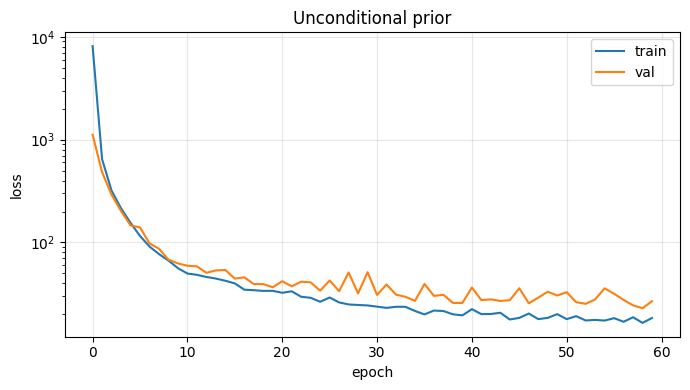

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(history['train_losses'], label='train')
if history.get('val_losses'): ax.plot(history['val_losses'], label='val')
ax.set_xlabel('epoch'); ax.set_ylabel('loss'); ax.set_yscale('log')
ax.legend(); ax.grid(alpha=0.3); ax.set_title('Unconditional prior')
plt.tight_layout(); plt.savefig('../results/ddrm_prior_loss.png', dpi=130)
plt.show()

## 5. DDRM restoration

Restore `dirty_sg.fits` using the prior plus the measured beam. Scored against
`clean_sg.fits` on the GI wiggle residual — the metric a plausible-looking image cannot fake.

In [8]:
assert SG_DIR, 'self-gravitating cube not attached; cannot run section 5'

import numpy as np
from astropy.io import fits
from src.training.ddrm import beam_transfer_function, ddrm_steps
from src.training.diffusion import data_transform, inverse_data_transform

# The line centre varies across the disk (that IS the rotation): measured, it spans
# channels 260-348. quadratic_moment1 finds each spectrum's PEAK channel, so a window
# narrower than that puts most spaxels' peaks on the window edge, flattens the velocity
# field, and the Keplerian fit collapses to its mstar bound. 10 channels gave mstar=50
# (the bound); 240-360 gives 0.538 Msun, matching the full-cube 0.572.
CHANNELS = list(range(240, 361, 2))     # 61 channels covering the full line-centre range

with fits.open(f'{SG_DIR}/clean_sg.fits', memmap=True) as h:
    sg_hdr = h[0].header
    sg_clean = np.stack([np.asarray(h[0].data[c], np.float32) for c in CHANNELS])
with fits.open(f'{SG_DIR}/dirty_sg.fits', memmap=True) as h:
    sg_dirty = np.stack([np.asarray(h[0].data[c], np.float32) for c in CHANNELS])

beam = fits.getdata('../results/self-gravitating/dirty_beam_recovered_v2.fits').astype(np.float64)
print(f'{len(CHANNELS)} channels | beam {beam.shape} peak {beam.max():.3f}')

61 channels | beam (129, 129) peak 0.991


In [9]:
import torch.nn.functional as Fn

def to01(a):
    lo, hi = a.min(), a.max()
    return (a - lo) / (hi - lo) if hi > lo else np.zeros_like(a), lo, hi

# Same beam every channel: build the operator once, not inside the loop.
transfer = beam_transfer_function(beam, (TARGET_SIZE, TARGET_SIZE), device=device)
transfer = transfer / transfer.max()              # unit gain at DC
print(f'transfer: {100*float((transfer > 0.01).float().mean()):.1f}% of modes above 1% gain')

restored = []
runner.model.eval()
for i in range(len(CHANNELS)):
    d01, lo, hi = to01(sg_dirty[i])
    t = torch.from_numpy(d01)[None, None].float().to(device)
    t = Fn.interpolate(t, (TARGET_SIZE, TARGET_SIZE), mode='bilinear', align_corners=False)
    y = data_transform(t)

    # RMS is in the cube's own units; the per-channel [0,1] rescale then data_transform's
    # [0,1]->[-1,1] map both have to be applied to it, hence /(hi-lo) and *2.
    sigma_y = float(sg_hdr.get('RMS', 0.0013)) / max(hi - lo, 1e-12) * 2.0

    with torch.no_grad():
        xs, _ = ddrm_steps(y, list(range(0, runner.num_timesteps, runner.num_timesteps // 50)),
                           runner.model, runner.betas, transfer, sigma_y=sigma_y,
                           prediction_type=PREDICTION)
    out = inverse_data_transform(xs[-1].to(device))
    out = Fn.interpolate(out, sg_clean.shape[-2:], mode='bilinear', align_corners=False)
    restored.append(out[0, 0].cpu().numpy() * (hi - lo) + lo)
    print(f'  channel {CHANNELS[i]} done', flush=True)

restored = np.stack(restored)
print('restored:', restored.shape)

transfer: 1.3% of modes above 1% gain
  channel 240 done
  channel 242 done
  channel 244 done
  channel 246 done
  channel 248 done
  channel 250 done
  channel 252 done
  channel 254 done
  channel 256 done
  channel 258 done
  channel 260 done
  channel 262 done
  channel 264 done
  channel 266 done
  channel 268 done
  channel 270 done
  channel 272 done
  channel 274 done
  channel 276 done
  channel 278 done
  channel 280 done
  channel 282 done
  channel 284 done
  channel 286 done
  channel 288 done
  channel 290 done
  channel 292 done
  channel 294 done
  channel 296 done
  channel 298 done
  channel 300 done
  channel 302 done
  channel 304 done
  channel 306 done
  channel 308 done
  channel 310 done
  channel 312 done
  channel 314 done
  channel 316 done
  channel 318 done
  channel 320 done
  channel 322 done
  channel 324 done
  channel 326 done
  channel 328 done
  channel 330 done
  channel 332 done
  channel 334 done
  channel 336 done
  channel 338 done
  channel 34

## 6. Score — does DDRM beat the beam-only floor?

In [10]:
from src.evaluation.moment_maps import generate_moment_maps, signal_mask
from src.evaluation.gi_wiggle import quadratic_moment1, fit_keplerian, wiggle_residual

velax = ((sg_hdr['CRVAL3'] + (np.array(CHANNELS) + 1 - sg_hdr['CRPIX3']) * sg_hdr['CDELT3'])
         * 1000.0)
AU_PER_PX = abs(sg_hdr['CDELT1']) * 3600.0 * sg_hdr.get('DIST_PC', 140.0)

m0, _, _ = generate_moment_maps('', data_velax=(sg_clean.astype(np.float64), velax))
mask = signal_mask(m0, frac=0.02)

MSTAR_BOUND = 50.0      # fit_keplerian's upper bound; hitting it means the fit failed

rows = {}
for tag, cube in (('clean', sg_clean), ('dirty', sg_dirty), ('DDRM', restored)):
    v0, _ = quadratic_moment1(cube.astype(np.float64), velax)
    m1 = v0 / 1000.0
    init = None if tag == 'clean' else {k: rows['clean']['geom'][k]
                                        for k in ('cx','cy','pa_deg','incl_deg')}
    geom = fit_keplerian(m1, mask, AU_PER_PX, init=init)
    rows[tag] = dict(m1=m1, geom=geom, resid=wiggle_residual(m1, geom))

# A fit pinned at the mstar bound is a failure, not a measurement, and every correlation
# computed from it is meaningless. Check before reporting anything.
degenerate = [t for t, r in rows.items() if r['geom']['mstar_msun'] > 0.9 * MSTAR_BOUND]
if degenerate:
    raise RuntimeError(
        f"Keplerian fit hit the mstar bound for {degenerate} -- the geometry is degenerate "
        f"and the correlations below would be meaningless. Widen CHANNELS to cover the full "
        f"line-centre range before reading any result.")

print(f"{'clean':8s} {rows['clean']['geom']['mstar_msun']:7.3f} "
      f"{rows['clean']['geom']['incl_deg']:6.1f}")
print(f"{'':8s} {'mstar':>7s} {'incl':>6s} {'raw r':>8s} {'resid r':>9s}")
for tag in ('dirty', 'DDRM'):
    ok = np.isfinite(rows['clean']['m1'][mask]) & np.isfinite(rows[tag]['m1'][mask])
    raw = np.corrcoef(rows['clean']['m1'][mask][ok], rows[tag]['m1'][mask][ok])[0, 1]
    ok2 = np.isfinite(rows['clean']['resid'][mask]) & np.isfinite(rows[tag]['resid'][mask])
    res = np.corrcoef(rows['clean']['resid'][mask][ok2], rows[tag]['resid'][mask][ok2])[0, 1]
    g = rows[tag]['geom']
    print(f"{tag:8s} {g['mstar_msun']:7.3f} {g['incl_deg']:6.1f} {raw:8.4f} {res:9.4f}")
    if tag == 'DDRM':
        print(f"\n  beam-only floor: 0.116")
        print(f"  DDRM:            {res:.4f}  ->  "
              f"{'RECOVERY' if res > 0.20 else 'no recovery beyond the floor'}")

clean      0.535   32.8
           mstar   incl    raw r   resid r
dirty      0.541   32.4   0.9930    0.1164
DDRM       1.626   18.9   0.9549    0.1223

  beam-only floor: 0.116
  DDRM:            0.1223  ->  no recovery beyond the floor


## 7. Figure

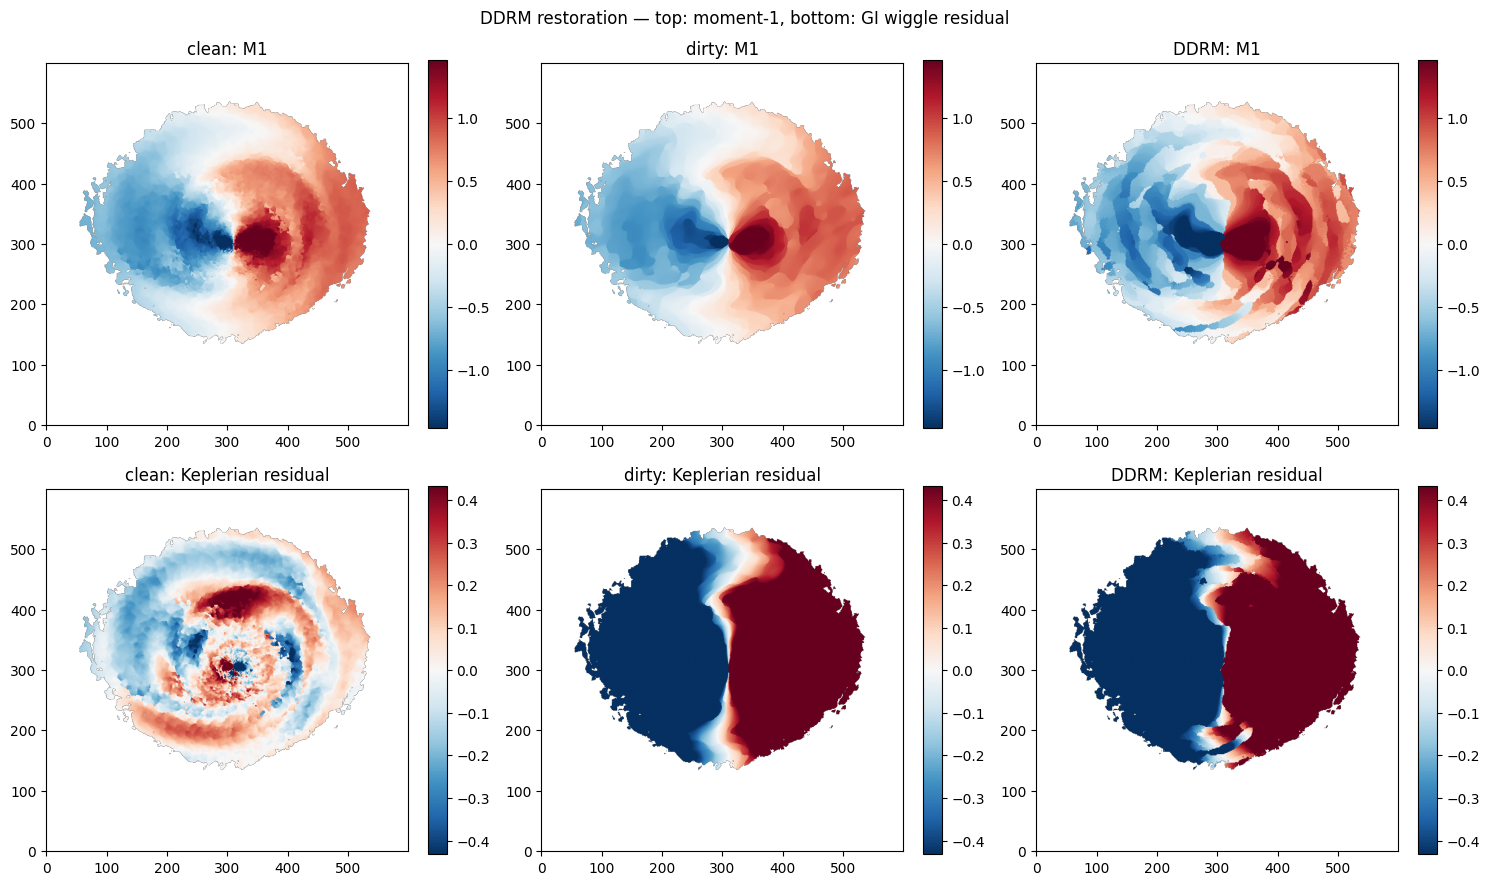

In [11]:
fig, ax = plt.subplots(2, 3, figsize=(15, 9))
vm1 = np.nanpercentile(np.abs(rows['clean']['m1'][mask]), 98)
vr  = np.nanpercentile(np.abs(rows['clean']['resid'][mask]), 98)
for i, tag in enumerate(('clean', 'dirty', 'DDRM')):
    im = ax[0, i].imshow(np.where(mask, rows[tag]['m1'], np.nan), cmap='RdBu_r',
                         vmin=-vm1, vmax=vm1, origin='lower')
    ax[0, i].set_title(f'{tag}: M1'); plt.colorbar(im, ax=ax[0, i], fraction=0.046)
    im2 = ax[1, i].imshow(np.where(mask, rows[tag]['resid'], np.nan), cmap='RdBu_r',
                          vmin=-vr, vmax=vr, origin='lower')
    ax[1, i].set_title(f'{tag}: Keplerian residual'); plt.colorbar(im2, ax=ax[1, i], fraction=0.046)
plt.suptitle('DDRM restoration — top: moment-1, bottom: GI wiggle residual')
plt.tight_layout(); plt.savefig('../results/ddrm_restoration.png', dpi=130)
plt.show()

## 8. Collect outputs

In [12]:
from src.evaluation.collect_outputs import collect_outputs
collect_outputs('07-ddrm-restoration', ['*.png', '*.csv', '*.pth'])


collected 154 file(s), 321.5 MiB -> /kaggle/working/outputs/07-ddrm-restoration/2026-08-28T070221_66c54a3
       3.64 MiB  1.png
       0.71 MiB  10.png
       0.07 MiB  11.png
       0.03 MiB  12.png
       0.67 MiB  13.png
       0.05 MiB  14.png
       0.07 MiB  15.png
       0.10 MiB  16.png
       1.78 MiB  17.png
       0.83 MiB  18.png
       0.06 MiB  19.png
       0.45 MiB  2.png
       0.03 MiB  3.png
       1.37 MiB  4.png
       0.04 MiB  5.png
       0.24 MiB  6.png
       0.13 MiB  7.png
       0.05 MiB  8.png
       1.62 MiB  9.png
       0.36 MiB  Exoplanet_WASP-96_b_NIRISS_transmission_spectrum_article.png
       0.29 MiB  Exoplanet_WASP-96_b_transit_light_curve_article.png
       0.30 MiB  V12_channel100.png
       0.05 MiB  V12_holdout_summary_chart.png
       0.04 MiB  V12_loss_curve.png
       0.96 MiB  V12_moment_comparison.png
       0.82 MiB  V12_moment_maps.png
       0.89 MiB  V12_val_channels.png
       0.27 MiB  V7_channel100.png
       0.04 MiB  V7_loss_cur

'/kaggle/working/outputs/07-ddrm-restoration/2026-08-28T070221_66c54a3'